In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"D:\Data Science\DataSet\creditcard.csv")
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,V29,Target
0,0.114697,0.796303,-0.149553,-0.823011,0.878763,-0.553152,0.939259,-0.108502,0.111137,-0.390521,...,-0.335776,-0.807853,-0.055940,-1.025281,-0.369557,0.204653,0.242724,0.085713,0.89,0
1,-0.039318,0.495784,-0.810884,0.546693,1.986257,4.386342,-1.344891,-1.743736,-0.563103,-0.616315,...,-1.377003,-0.072200,-0.197573,1.014807,1.011293,-0.167684,0.113136,0.256836,85.00,0
2,2.275706,-1.531508,-1.021969,-1.602152,-1.220329,-0.462376,-1.196485,-0.147058,-0.950224,1.560463,...,-0.193271,-0.103533,0.150945,-0.811083,-0.197913,-0.128446,0.014197,-0.051289,42.70,0
3,1.940137,-0.357671,-1.210551,0.382523,0.050823,-0.171322,-0.109124,-0.002115,0.869258,-0.001965,...,0.157994,0.650355,0.034206,0.739535,0.223605,-0.195509,-0.012791,-0.056841,29.99,0
4,1.081395,-0.502615,1.075887,-0.543359,-1.472946,-1.065484,-0.443231,-0.143374,1.659826,-1.131238,...,0.224157,0.821209,-0.137223,0.986259,0.563228,-0.574206,0.089673,0.052036,68.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56957,2.030797,-0.825073,-0.729555,-0.519187,-0.639893,-0.169482,-0.619049,-0.017902,-0.578643,0.915645,...,-0.790167,-1.825357,0.600083,0.702623,-0.782688,-0.007105,-0.041057,-0.038601,42.42,0
56958,-0.263947,1.119700,-0.639394,-0.880567,1.194120,-0.310693,0.962087,-0.088880,0.386664,0.195362,...,-0.448081,-0.893010,0.004678,0.062555,-0.347536,0.106510,0.274117,-0.036263,7.99,0
56959,2.206867,-0.748559,-1.443015,-1.101542,-0.332197,-0.646931,-0.536272,-0.129437,-0.712381,1.057616,...,0.471336,1.314052,0.038930,0.747315,0.158017,0.021897,-0.046200,-0.072586,1.00,0
56960,1.430579,-0.842354,0.415998,-1.328439,-1.284654,-0.888110,-0.653237,-0.238164,-2.220845,1.350845,...,-0.577415,-1.323989,0.336843,0.329714,-0.007425,-0.636401,0.037095,0.029180,30.00,0


In [4]:
df.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
Target    0
dtype: int64

In [8]:
fraud_count = df[df['Target'] == 1].shape[0]
genuine_count = df[df['Target'] == 0].shape[0]

# Calculate the percentage of fraudulent transactions
total_transactions = df.shape[0]
fraud_percentage = (fraud_count / total_transactions) * 100

In [10]:
fraud_count

98

In [11]:
genuine_count

56864

In [12]:
fraud_percentage

0.17204452090867595

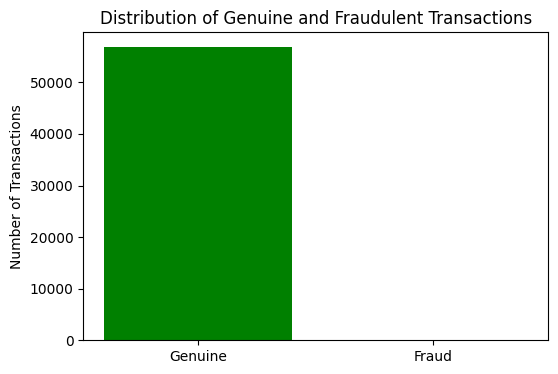

In [14]:
# Count the number of fraudulent and genuine transactions
fraud_count = df[df['Target'] == 1].shape[0]
genuine_count = df[df['Target'] == 0].shape[0]

# Plotting the bar graph
plt.figure(figsize=(6, 4))
plt.bar(['Genuine', 'Fraud'], [genuine_count, fraud_count], color=['green', 'red'])
plt.title('Distribution of Genuine and Fraudulent Transactions')
plt.ylabel('Number of Transactions')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

In [21]:
x=df.drop(columns=['Target'])
y=df['Target']

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [23]:
print(f"Training set size: {x_train.shape[0]} samples")
print(f"Test set size: {x_test.shape[0]} samples")

Training set size: 39873 samples
Test set size: 17089 samples


# Decision Tree

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [36]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(x_test)

cm=confusion_matrix(y_test, y_pred_dt)
cm

array([[17048,    14],
       [    5,    22]])

In [37]:
accuracy_score(y_test,y_pred_dt)

0.9988881736789748

# Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf=RandomForestClassifier(n_estimators=50,random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [43]:
y_pred_rf=rf.predict(x_test)

In [45]:
cm=confusion_matrix(y_test,y_pred_rf)
cm

array([[17061,     1],
       [    6,    21]])

In [46]:
accuracy_score(y_test,y_pred_rf)

0.9995903797764644

In [49]:
y_pred_dt = dt_model.predict(x_test)

y_pred_rf = rf.predict(x_test)

In [51]:
pd.DataFrame(y_pred_dt)

,0
0,0
1,0
2,0
3,0
4,0
...,...
17084,0
17085,0
17086,0
17087,0


In [52]:
pd.DataFrame(y_pred_rf)

,0
0,0
1,0
2,0
3,0
4,0
...,...
17084,0
17085,0
17086,0
17087,0


In [53]:
acc_score_dt=accuracy_score(y_test,y_pred_dt)
acc_score_rf=accuracy_score(y_test,y_pred_rf)

In [54]:
acc_score_dt

0.9988881736789748

In [55]:
acc_score_rf

0.9995903797764644